# 02 - Range, endurance, loiter and payload-range

References: Roskam & Lan, Chapter 11 (Secs. 11.1 propeller aircraft, 11.2 jets,
11.3 payload-range, 11.4 fuel reserves); Anderson, Secs. 5.13-5.15.
This notebook extends `Capitolo9/AutonomieMotoelica.ipynb`, which derives the
Breguet equations for propeller aircraft.

In [1]:
# --- Setup -------------------------------------------------------------------
# The notebooks live in PrestazioniRoskam/, one level below the repository root,
# where the `aircraft_performance` package is. Make it importable:
import sys
import pathlib
ROOT = pathlib.Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

import aircraft_performance as ap
from aircraft_performance import units as u
from aircraft_performance.atmosphere import isa
from aircraft_performance.plotting import apply_style, reference_line
from aircraft_performance.reporting import print_table

apply_style()
print(f"aircraft_performance v{ap.__version__} ready")

from aircraft_performance import range_endurance as rng, aerodynamics as aero

single = ap.examples.light_single_piston()
atr = ap.examples.regional_turboprop()
jet = ap.examples.business_jet_giv()
G0 = u.G0

aircraft_performance v1.0.0 ready


## 1. The fundamental relations

The weight decreases only because fuel is burnt, $\dot W = -\dot W_f$. The fuel
weight flow is (Roskam Eqns 11.1, 11.47)

$$
\dot W_f = c\,P_{shaft} = \frac{c\,D\,V}{\eta_p}\quad\text{(propeller)},\qquad
\dot W_f = c_t\,T = c_t\,D \quad\text{(jet)}.
$$

Dividing $dt = -dW/\dot W_f$ and $ds = V_g\,dt$ by the weight change we obtain
the **specific endurance** and the **specific range** (Eqns 11.28, 11.30):

$$
\text{S.E.} = -\frac{dt}{dW} = \frac{1}{\dot W_f}, \qquad
\text{S.R.} = -\frac{ds}{dW} = \frac{V_g}{\dot W_f},
\qquad E = \int_{W_1}^{W_0}\text{S.E.}\,dW, \quad R = \int_{W_1}^{W_0}\text{S.R.}\,dW
$$

where $V_g = V - V_{headwind}$ is the ground speed. These integrals are the
*accurate* method; the Breguet equations are their closed-form solutions under
special flight programs.

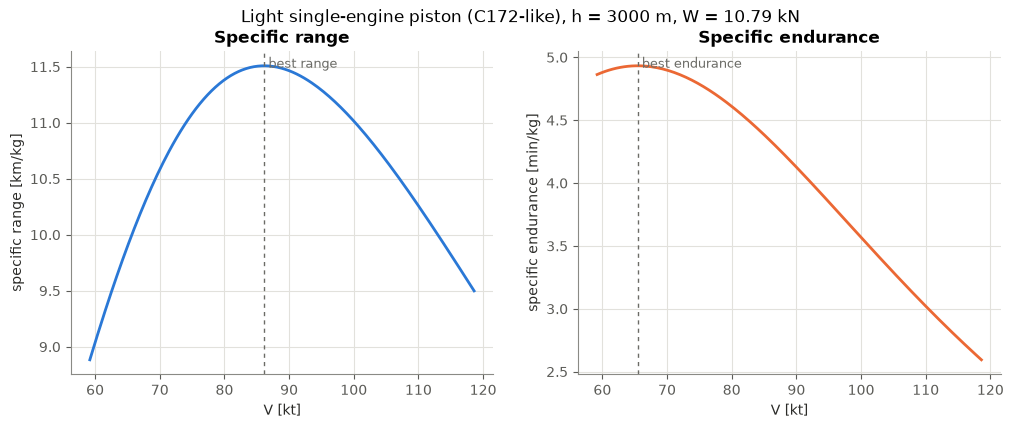

       optimum  V [kt]     CL  polar point CL
--------------  ------  -----  --------------
    best range    86.2  0.755           0.755
best endurance    65.5  1.308           1.308


In [2]:
h = 3000.0
W = single.weight
speeds = ap.level_flight.level_flight_speeds(single, h, W)
V = np.linspace(speeds.V_min, speeds.V_max, 200)
SR = rng.specific_range(single, V, h, W) * G0 / 1000       # km per kg of fuel
SE = rng.specific_endurance(single, V, h, W) * G0 / 3600   # hours per kg of fuel

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
a1.plot(V / u.KT, SR)
a1.set_xlabel("V [kt]"); a1.set_ylabel("specific range [km/kg]"); a1.set_title("Specific range")
a2.plot(V / u.KT, SE * 60, color="#eb6834")
a2.set_xlabel("V [kt]"); a2.set_ylabel("specific endurance [min/kg]"); a2.set_title("Specific endurance")
br = rng.best_range_speed(single, h, W)
be = rng.best_endurance_speed(single, h, W)
reference_line(a1, br["V"] / u.KT, label="best range")
reference_line(a2, be["V"] / u.KT, label="best endurance")
fig.suptitle(f"{single.name}, h = {h:.0f} m, W = {W/1000:.2f} kN")
plt.show()

pol = single.polar()
print_table(["optimum", "V [kt]", "CL", "polar point CL"],
            [["best range", br["V"] / u.KT, br["CL"], pol.point_E.CL],
             ["best endurance", be["V"] / u.KT, be["CL"], pol.point_P.CL]],
            ["{}", "{:.1f}", "{:.3f}", "{:.3f}"])

For a propeller aircraft with constant $\eta_p$ and $c$, the fuel flow is
proportional to the power required: best endurance at minimum power (point P),
best range at minimum $D$ (point E), exactly as found numerically.

## 2. Breguet equations

### Propeller aircraft (Roskam Eqns 11.7-11.8)

$$
R = \frac{\eta_p}{c}\,\frac{C_L}{C_D}\,\ln\frac{W_0}{W_1},\qquad
E = \frac{\eta_p}{c}\,\frac{C_L^{3/2}}{C_D}\,\sqrt{2\rho S}\left(\frac{1}{\sqrt{W_1}}-\frac{1}{\sqrt{W_0}}\right)
$$

(the endurance formula assumes constant altitude and $C_L$).

### Jet aircraft (Roskam Eqns 11.55, 11.57, 11.60)

$$
R_{h,C_L} = \frac{2}{c_t}\sqrt{\frac{2}{\rho S}}\,\frac{C_L^{1/2}}{C_D}\left(\sqrt{W_0}-\sqrt{W_1}\right),\qquad
R_{V,C_L} = \frac{V}{c_t}\,\frac{C_L}{C_D}\,\ln\frac{W_0}{W_1},\qquad
E = \frac{1}{c_t}\,\frac{C_L}{C_D}\,\ln\frac{W_0}{W_1}
$$

| | propeller | jet |
|---|---|---|
| max range | point E, $\max C_L/C_D$ | point A, $\max C_L^{1/2}/C_D$ (constant altitude) |
| max endurance | point P, $\max C_L^{3/2}/C_D$ | point E, $\max C_L/C_D$ |
| effect of altitude | range independent of altitude; endurance better low | range better high ($1/\sqrt\rho$); endurance independent |

### Revisiting the `Capitolo9` exercise

Light aircraft, 1,100 kg, 100 kg of fuel, $\eta_p=0.75$, $c = 0.45$ lb/(hp h),
$C_{D_0}=0.030$, $e=0.8$, $b=11$ m, $S=16$ m$^2$.

In [3]:
pol = single.polar()
prop = single.propulsion
W0, W1 = 1100 * G0, 1000 * G0
E = pol.point_E
R = rng.breguet_range_propeller(prop.propeller_efficiency, prop.bsfc, E.lift_to_drag, W0, W1)
rho = isa(4000.0).density
P = pol.point_P
End = rng.breguet_endurance_propeller(prop.propeller_efficiency, prop.bsfc, P.CL, P.CD, rho,
                                      single.wing_area, W0, W1)
print(f"Point E: CL = {E.CL:.4f}, CD = {E.CD:.4f} (= 2 CD0), E_max = {E.lift_to_drag:.2f}")
print(f"Maximum range     R = {R/1000:.1f} km")
print(f"Maximum endurance E = {End/3600:.2f} h at 4,000 m (point P: CL = {P.CL:.3f}, CD = {P.CD:.3f})")
print(f"Loiter speed at start / end: {aero.speed_for_lift_coefficient(W0, single.wing_area, rho, P.CL):.1f}"
      f" / {aero.speed_for_lift_coefficient(W1, single.wing_area, rho, P.CL):.1f} m/s")

Point E: CL = 0.7551, CD = 0.0600 (= 2 CD0), E_max = 12.59
Maximum range     R = 1206.5 km
Maximum endurance E = 8.38 h at 4,000 m (point P: CL = 1.308, CD = 0.120)
Loiter speed at start / end: 35.5 / 33.8 m/s


> **Note for the `Capitolo9` notebook.** In the cell *"Esercizio applicativo -
> Calcolo del Range"* the drag coefficient at point E is written `CDE = 4 * CD0`;
> at point E the drag coefficient is $2C_{D_0}$ ($4C_{D_0}$ belongs to point P),
> so the range printed there (603 km) is half of the correct value computed
> above. Likewise, the *loiter* speeds in the first and third exercises of that
> notebook are computed with `CLE`, whereas maximum endurance for a propeller
> aircraft is flown at point P (as correctly stated in its text).

## 3. Numerical cruise: three flight programs

`rng.cruise` integrates S.R. and S.E. numerically for the three classic programs:

1. `constant_altitude_constant_CL` - the pilot reduces speed as fuel burns;
2. `constant_altitude_constant_speed` - the usual ATC-constrained cruise, $C_L$ and
   $L/D$ drift during the flight;
3. `constant_speed_constant_CL` - the *cruise-climb*: the altitude increases so
   that $\rho/W$ is constant.

Each result is checked against the corresponding closed form (Breguet, or the
$\arctan$ solution for constant altitude and speed).

In [4]:
W0 = jet.weight
W1 = W0 - 0.9 * jet.max_fuel_mass * G0
h0 = 11000.0
CL0 = 0.40      # initial cruise CL: M ~ 0.76 at 11 km, below the drag-divergence Mach number

res = {prog: rng.cruise(jet, W0, W1, prog, h0, CL=CL0) for prog in rng.CRUISE_PROGRAMS}
rho0 = isa(h0).density
pol = jet.polar()
ct = jet.propulsion.tsfc
V0 = res["constant_altitude_constant_CL"].speed[0]
closed = {
    "constant_altitude_constant_CL": rng.breguet_range_jet_constant_altitude(ct, rho0, jet.wing_area, CL0, pol.drag_coefficient(CL0), W0, W1),
    "constant_altitude_constant_speed": rng.range_constant_altitude_speed_jet(V0, rho0, jet.wing_area, pol, ct, W0, W1),
    "constant_speed_constant_CL": rng.breguet_range_jet_constant_speed(V0, ct, CL0 / pol.drag_coefficient(CL0), W0, W1),
}
print_table(["program", "range numerical [km]", "closed form [km]", "time [h]", "final h [m]", "final V [m/s]"],
            [[p, r.range / 1000, closed[p] / 1000, r.endurance / 3600, r.altitude[-1], r.speed[-1]] for p, r in res.items()],
            ["{}", "{:.1f}", "{:.1f}", "{:.2f}", "{:.0f}", "{:.1f}"])

                         program  range numerical [km]  closed form [km]  time [h]  final h [m]  final V [m/s]
--------------------------------  --------------------  ----------------  --------  -----------  -------------
   constant_altitude_constant_CL                6829.5            6829.5      9.43        11000          179.3
constant_altitude_constant_speed                7260.0            7260.0      8.97        11000          224.8
      constant_speed_constant_CL                7630.4            7630.4      9.43        13867          224.8


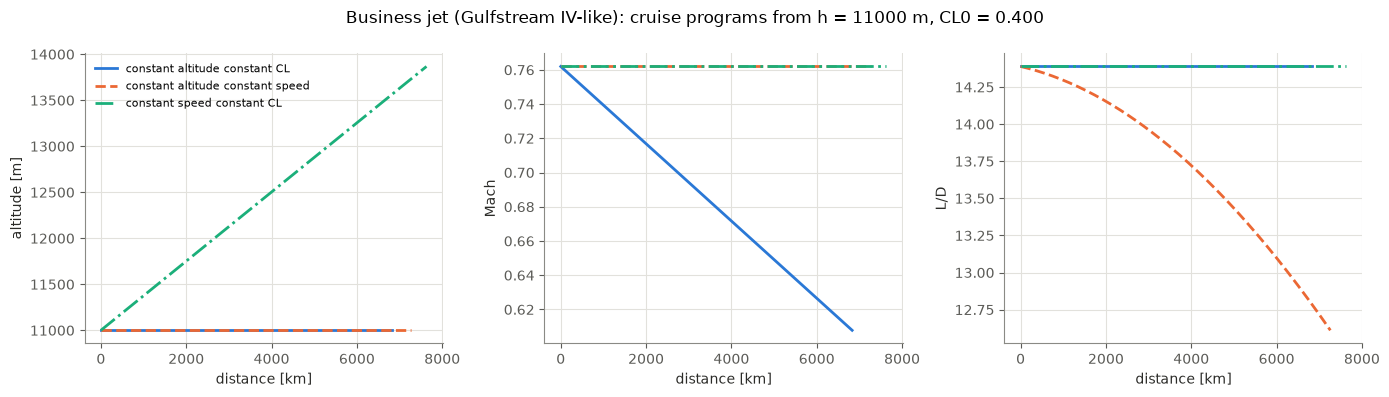

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for prog, r in res.items():
    label = prog.replace("_", " ")
    axes[0].plot(r.distance / 1000, r.altitude, label=label)
    axes[1].plot(r.distance / 1000, r.speed / isa(r.altitude).speed_of_sound, label=label)
    axes[2].plot(r.distance / 1000, r.lift_to_drag, label=label)
axes[0].set_ylabel("altitude [m]"); axes[1].set_ylabel("Mach"); axes[2].set_ylabel("L/D")
for ax in axes:
    ax.set_xlabel("distance [km]")
axes[0].legend(fontsize=8)
fig.suptitle(f"{jet.name}: cruise programs from h = {h0:.0f} m, CL0 = {CL0:.3f}")
plt.tight_layout()
plt.show()

Observations (Roskam Sec. 11.1.4, Anderson Sec. 5.13.3):

* the **cruise-climb** gives the longest range: it keeps both $V$ and $L/D$
  at their initial values, climbing almost 3 km in this case;
* between the two constant-altitude programs, the ranking depends on where the
  initial $C_L$ lies with respect to point A (for a jet, range $\propto V\,L/D$,
  maximum at point A). Here $C_{L_0}=0.40$ is *above* $C_{L_A}=0.25$: flying at
  constant speed, $C_L$ decreases towards point A as fuel burns and the
  speed stays high, so this program beats the constant-$C_L$ one, in which the
  speed keeps decreasing. Starting below point A the opposite would happen
  (try it: exercise 4);
* in practice airliners approximate the cruise-climb with **step climbs**
  when ATC allows it.

## 4. Roskam and Anderson examples

In [6]:
from aircraft_performance.aerodynamics import ParabolicDragPolar
# Roskam Example 11.1 - propeller cargo aircraft, outbound leg of 1,500 nm at (L/D)max
pol = ParabolicDragPolar(CD0=0.0200, K=0.05)
c = u.bsfc_to_si(0.45)
W0 = 30000 * u.LBF
W1 = W0 / np.exp(1500 * u.NM * c / (0.87 * pol.max_lift_to_drag))    # Breguet inverted
print(f"Roskam 11.1: E_max = {pol.max_lift_to_drag:.1f} (15.8), W_end = {W1/u.LBF:,.0f} lb (25,805), "
      f"fuel = {(W0-W1)/u.LBF:,.0f} lb (4,195)")

# Roskam Examples 11.2-11.3 - small jet transport at 35,000 ft
pol = ParabolicDragPolar(CD0=0.019, K=0.055)
ct = u.tsfc_to_si(0.65)
W0, W1 = 49000 * u.LBF, 39000 * u.LBF
atm = isa(35000 * u.FT)
V = 0.75 * atm.speed_of_sound
A = pol.point_A
rows = [
    ["11.2  M = 0.75, L/D = 14.8 (average)", rng.breguet_range_jet_constant_speed(V, ct, 14.8, W0, W1) / u.NM, 2247],
    ["11.3  constant altitude, point A", rng.breguet_range_jet_constant_altitude(ct, atm.density, 500 * u.FT2, A.CL, A.CD, W0, W1) / u.NM, 2331],
    ["11.3  M = 0.75, (L/D)max", rng.breguet_range_jet_constant_speed(V, ct, pol.max_lift_to_drag, W0, W1) / u.NM, 2353],
]
print_table(["case", "range [nm]", "Roskam [nm]"], rows, ["{}", "{:.0f}", "{:.0f}"])
print(f"11.2 endurance = {rng.breguet_endurance_jet(ct, 14.8, W0, W1)/3600:.2f} h (5.2 h)")
V_A = aero.speed_for_lift_coefficient(W0, 500 * u.FT2, atm.density, A.CL)
print(f"11.3 speed for point A at the start of cruise: M = {V_A / atm.speed_of_sound:.2f} "
      "(Roskam: 0.91, 'way too high' - compressibility is ignored by the parabolic polar)")

Roskam 11.1: E_max = 15.8 (15.8), W_end = 25,806 lb (25,805), fuel = 4,194 lb (4,195)
                                case  range [nm]  Roskam [nm]
------------------------------------  ----------  -----------
11.2  M = 0.75, L/D = 14.8 (average)        2247         2247
    11.3  constant altitude, point A        2332         2331
            11.3  M = 0.75, (L/D)max        2348         2353
11.2 endurance = 5.20 h (5.2 h)
11.3 speed for point A at the start of cruise: M = 0.91 (Roskam: 0.91, 'way too high' - compressibility is ignored by the parabolic polar)


## 5. Effect of wind

A headwind reduces the ground speed but not the fuel flow: the range decreases
and the best-range speed *increases* (Roskam Fig. 11.7: the tangent to the
$P_{req}(V)$ curve is drawn from the point $V = V_{headwind}$). The endurance and
the best-endurance speed do not depend on wind.

In [7]:
h = 3000.0
rows = []
for hw_kt in (-20, -10, 0, 10, 20, 30):
    b = rng.best_range_speed(single, h, headwind=hw_kt * u.KT)
    rows.append([hw_kt, b["V"] / u.KT, b["specific_range"] * G0 / 1000])
print("Light single at 3,000 m (positive = headwind)")
print_table(["headwind [kt]", "best-range V [kt]", "S.R. [km/kg]"], rows, ["{:+.0f}", "{:.1f}", "{:.2f}"])

Light single at 3,000 m (positive = headwind)
headwind [kt]  best-range V [kt]  S.R. [km/kg]
-------------  -----------------  ------------
          -20               82.0         14.25
          -10               83.9         12.86
           +0               86.2         11.51
          +10               88.9         10.19
          +20               92.4          8.93
          +30               96.6          7.73


## 6. Loiter (maximum endurance)

`rng.loiter` flies the optimum endurance lift coefficient at constant altitude:
point P for propeller aircraft, point E for jets. If point P is too close to the
stall (as it happens for the turboprop below) the lift coefficient is limited
to that of $1.2\,V_S$ and a warning explains why.

In [8]:
rows = []
for aircraft in (single, atr, jet):
    W0 = aircraft.weight
    W1 = W0 - 0.3 * aircraft.max_fuel_mass * G0
    for h in (1000.0, 5000.0):
        r = rng.loiter(aircraft, W0, W1, h)
        rows.append([aircraft.name, h, r.CL[0], r.speed[0] / u.KT, r.endurance / 3600,
                     (W0 - W1) / G0 / (r.endurance / 3600)])
print_table(["aircraft", "h [m]", "CL", "V start [kt]", "endurance [h]", "mean fuel flow [kg/h]"], rows,
            ["{}", "{:.0f}", "{:.3f}", "{:.0f}", "{:.2f}", "{:.0f}"])

/tmp/ipykernel_4646/2338203982.py:6: PerformanceWarning: Optimum loiter CL = 1.31 is too close to the stall; using CL = 1.11 (V = 1.2 V_S).
  r = rng.loiter(aircraft, W0, W1, h)
/tmp/ipykernel_4646/2338203982.py:6: PerformanceWarning: Optimum loiter CL = 1.59 is too close to the stall; using CL = 1.11 (V = 1.2 V_S).
  r = rng.loiter(aircraft, W0, W1, h)


                              aircraft  h [m]     CL  V start [kt]  endurance [h]  mean fuel flow [kg/h]
--------------------------------------  -----  -----  ------------  -------------  ---------------------
Light single-engine piston (C172-like)   1000  1.111            64           4.18                     11
Light single-engine piston (C172-like)   5000  1.111            79           3.40                     13
      Regional turboprop (ATR 72-like)   1000  1.111           151           3.85                    389
      Regional turboprop (ATR 72-like)   5000  1.111           186           3.14                    478
     Business jet (Gulfstream IV-like)   1000  0.433           240           2.70                   1485
     Business jet (Gulfstream IV-like)   5000  0.433           295           2.70                   1485


Note how the endurance of the jet is (almost) independent of altitude (only the
thrust-lapse check depends on it), whereas propeller aircraft loiter longer at
low altitude ($E\propto\sqrt\rho$).

## 7. Payload-range diagram (Roskam Sec. 11.3.1, Fig. 11.28)

Corner points: **A** maximum payload, no fuel; **B** maximum payload with the
fuel allowed by the maximum take-off mass (harmonic range); **C** full tanks,
payload reduced to stay within MTOM; **D** full tanks, zero payload (ferry
range). Here 10 % of the loaded fuel is kept as reserve + non-cruise fuel.

Regional turboprop (ATR 72-like)
point  payload [kg]  fuel [kg]  TOM [kg]  range [km]
-----  ------------  ---------  --------  ----------
    A          7500          0     20500           0
    B          7500       2300     22800        1454
    C          4800       5000     22800        3359
    D             0       5000     18000        4395

Business jet (Gulfstream IV-like)
point  payload [kg]  fuel [kg]  TOM [kg]  range [km]
-----  ------------  ---------  --------  ----------
    A          2950          0     19050           0
    B          2950      13381     32431        7076
    C          2950      13381     32431        7076
    D             0      13381     29481        7521



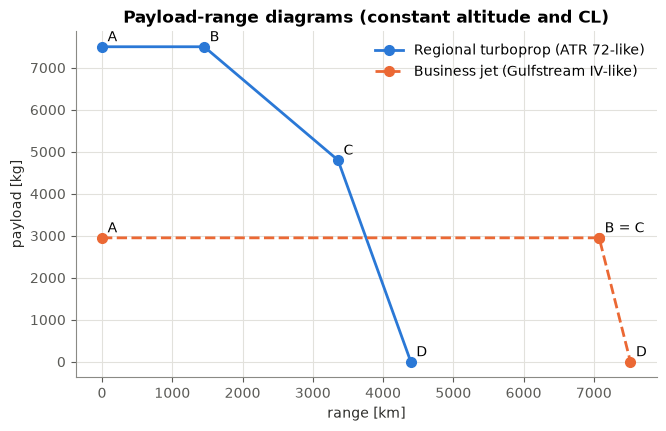

In [9]:
fig, ax = plt.subplots()
for aircraft, h, CL in ((atr, 5000.0, 0.70), (jet, 12000.0, 0.45)):
    pr = rng.payload_range(aircraft, h, CL=CL, reserve_fraction=0.10)
    ax.plot(pr["range"] / 1000, pr["payload"], marker="o", label=aircraft.name)
    same_BC = np.isclose(pr["B"]["range"], pr["C"]["range"]) and np.isclose(pr["B"]["payload"], pr["C"]["payload"])
    for k in "ABCD":
        if k == "C" and same_BC:
            continue            # coincident corner points: one label "B = C"
        text = "B = C" if (k == "B" and same_BC) else k
        ax.annotate(text, (pr[k]["range"] / 1000, pr[k]["payload"]), xytext=(4, 4), textcoords="offset points")
    print(aircraft.name)
    print_table(["point", "payload [kg]", "fuel [kg]", "TOM [kg]", "range [km]"],
                [[k, pr[k]["payload"], pr[k]["fuel"], pr[k]["takeoff_mass"], pr[k]["range"] / 1000] for k in "ABCD"],
                ["{}", "{:.0f}", "{:.0f}", "{:.0f}", "{:.0f}"])
    print()
ax.set_xlabel("range [km]"); ax.set_ylabel("payload [kg]")
ax.set_title("Payload-range diagrams (constant altitude and CL)")
ax.legend()
plt.show()

For the business jet the maximum payload *and* full tanks fit within the MTOM,
so points B and C coincide: range can then be traded for payload only along
C-D. For the turboprop B and C are distinct: beyond the harmonic range each
extra kilogram of fuel costs one kilogram of payload.

## 8. Fuel reserves (Roskam Sec. 11.4, Table 11.3)

The fuel actually available for range is the loaded fuel minus the fuel for
taxi, take-off, climb, descent and landing, minus the **reserves** required by
the operating rules. A summary of FAR 121.645 (turbine aircraft, flag and
supplemental carriers):

| requirement | fuel to... |
|---|---|
| a) | fly to and land at the most distant alternate airport |
| b) | fly for 10 % of the total flight time to destination |
| c) | hold 30 min at 1,500 ft above the alternate |
| d) (no alternate) | fly 2 h at normal cruise consumption |

Reserves = max{a + b + c, d}. For non-turbine and turboprop aircraft (121.641)
a 45 min reserve replaces c), and FAR 135.209 (VFR) requires 30 min by day and
45 min by night. These rules can be modelled with the functions above: e.g.
the 30 min holding fuel is `rng.loiter(...)` evaluated at 1,500 ft.

## 9. Exercises

1. Compute the fuel required by the business jet for a 30 min hold at 1,500 ft
   at the end of a 4,000 km cruise.
2. For the turboprop, compare the range at 3,000 m and 7,000 m flying at the
   same $C_L$: why is the propeller range almost independent of altitude?
3. Repeat the payload-range diagram with `program="constant_speed_constant_CL"`.
4. Repeat the comparison of the three cruise programs with $C_{L_0} = 0.20$
   (below point A) and explain the new ranking.